In [1]:
!pip install seaborn
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
def plot_scale_similarity(weights, k_value=8):

    # Compute Cosine Similarity Matrix
    # Shape: (K, d_model) -> (K, K)
    similarity = F.cosine_similarity(weights.unsqueeze(1), weights.unsqueeze(0), dim=-1)
    print("Cosine Similarity Matrix:\n", similarity)

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        similarity.numpy(),
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        xticklabels=[f"K{i}" for i in range(k_value)],
        yticklabels=[f"K{i}" for i in range(k_value)],
        vmin=-1, vmax=1
    )

    plt.title("Cosine Similarity of SAPE Scale Table Embeddings")
    plt.xlabel("Scale Anchor Index")
    plt.ylabel("Scale Anchor Index")
    # plt.savefig("sape_similarity_heatmap.pdf", bbox_inches="tight")
    plt.show()


# Usage with a Detectron2/Adet model
# plot_scale_similarity(trained_model)

Cosine Similarity Matrix:
 tensor([[ 1.0000,  0.0125, -0.0241, -0.0019,  0.0271,  0.1210, -0.1080, -0.0155],
        [ 0.0125,  1.0000,  0.0188,  0.0921,  0.0064, -0.0822,  0.0397,  0.0539],
        [-0.0241,  0.0188,  1.0000,  0.0478, -0.1060, -0.0403, -0.0015, -0.0610],
        [-0.0019,  0.0921,  0.0478,  1.0000,  0.1371,  0.0266, -0.0791, -0.0416],
        [ 0.0271,  0.0064, -0.1060,  0.1371,  1.0000,  0.1689, -0.1960, -0.0256],
        [ 0.1210, -0.0822, -0.0403,  0.0266,  0.1689,  1.0000, -0.0504, -0.0657],
        [-0.1080,  0.0397, -0.0015, -0.0791, -0.1960, -0.0504,  1.0000,  0.1094],
        [-0.0155,  0.0539, -0.0610, -0.0416, -0.0256, -0.0657,  0.1094,  1.0000]])


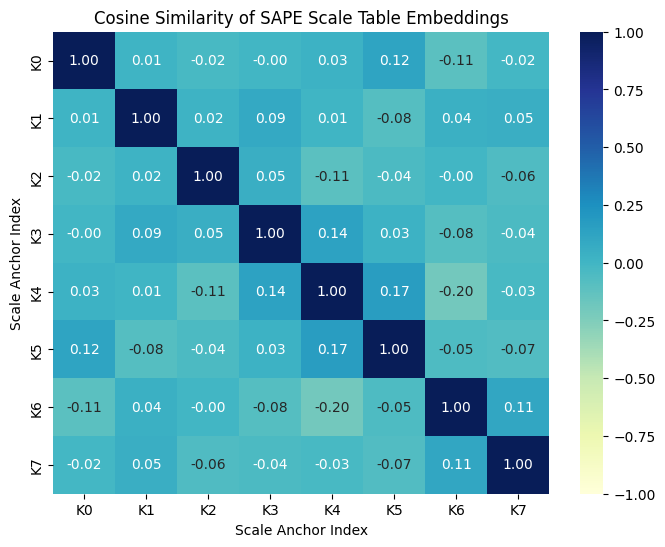

In [14]:
model_path1 = (
    "../output/forbin_stamp/forbin_stamps_fold0/model_best.pth"
)
torch_model1 = torch.load(model_path1)
torch_model1 = dict(torch_model1["model"])
weights1 = (
    torch_model1["detection_transformer.transformer.scale_embedder.scale_table"]
    .detach()
    .cpu()
)
plot_scale_similarity(weights1)

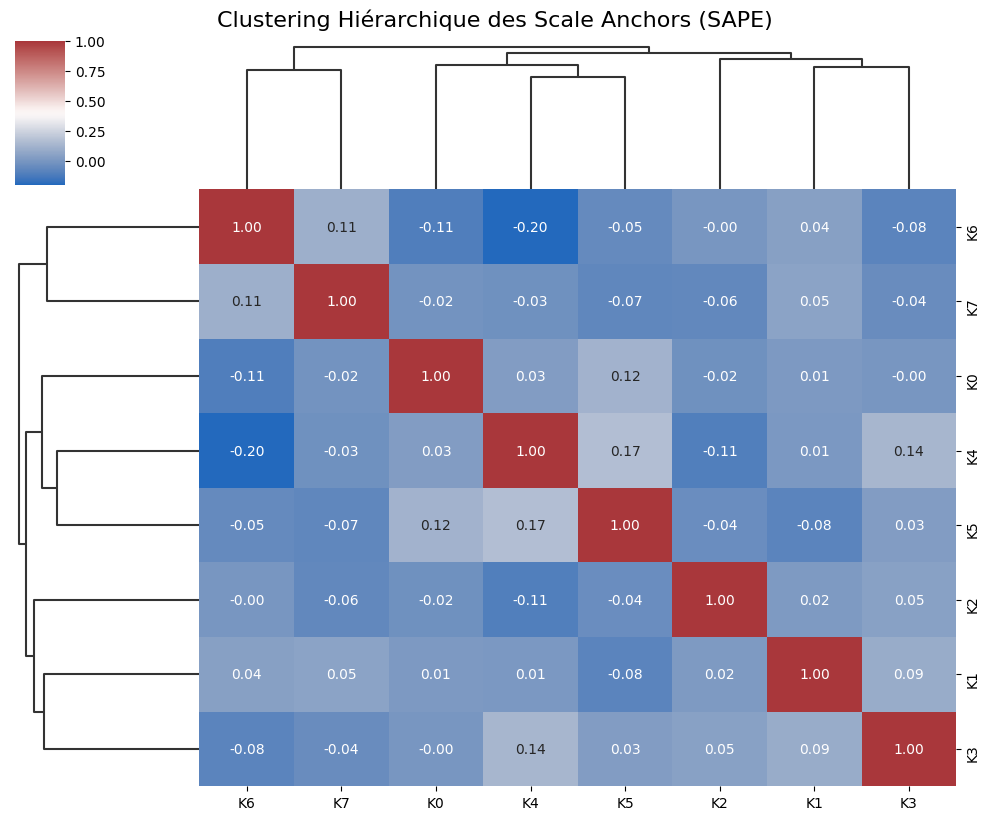

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.cluster.hierarchy import linkage, dendrogram
import pandas as pd


def plot_scale_clustering(weights, k_value=8):
    # 1. Calcul de la similarité cosine
    norm_weights = F.normalize(weights, p=2, dim=1)
    similarity = torch.mm(norm_weights, norm_weights.t()).detach().cpu().numpy()

    # 2. Conversion en DataFrame pour un affichage propre
    labels = [f"K{i}" for i in range(k_value)]
    df = pd.DataFrame(similarity, index=labels, columns=labels)

    # 3. Création du Clustermap
    # 'metric=cosine' et 'method=complete' sont idéaux pour ce type de données
    g = sns.clustermap(
        df,
        annot=True,
        fmt=".2f",
        cmap="vlag",  # Palette divergente (bleu-blanc-rouge) centrée sur 0
        vmin=-0.2,
        vmax=1.0,  # On ajuste pour bien voir les petites variations
        figsize=(10, 8),
        tree_kws=dict(linewidths=1.5),
    )

    g.fig.suptitle(
        "Clustering Hiérarchique des Scale Anchors (SAPE)", y=1.02, fontsize=16
    )
    plt.show()


# Utilisation :
plot_scale_clustering(weights1)

Cosine Similarity Matrix:
 tensor([[ 1.0000, -0.0750,  0.0175,  0.0036,  0.0084, -0.0607, -0.0026,  0.0088],
        [-0.0750,  1.0000,  0.0177,  0.0645, -0.0565, -0.0602,  0.1268, -0.0270],
        [ 0.0175,  0.0177,  1.0000,  0.0182, -0.0651,  0.0890,  0.0074, -0.0617],
        [ 0.0036,  0.0645,  0.0182,  1.0000, -0.0457,  0.0349,  0.0679, -0.0366],
        [ 0.0084, -0.0565, -0.0651, -0.0457,  1.0000, -0.0412, -0.0920, -0.0128],
        [-0.0607, -0.0602,  0.0890,  0.0349, -0.0412,  1.0000,  0.1295,  0.0293],
        [-0.0026,  0.1268,  0.0074,  0.0679, -0.0920,  0.1295,  1.0000,  0.0802],
        [ 0.0088, -0.0270, -0.0617, -0.0366, -0.0128,  0.0293,  0.0802,  1.0000]])


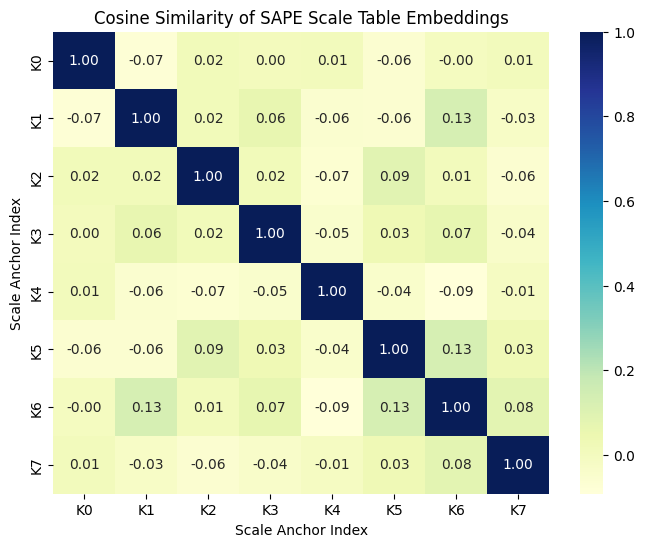

In [36]:
model_path0 = "../output/forbin_stamp/forbin_stamps_fold1/model_0000999.pth"
torch_model0 = torch.load(model_path0)
torch_model0 = dict(torch_model0["model"])
weights0 = (
    torch_model0["detection_transformer.transformer.scale_embedder.scale_table"]
    .detach()
    .cpu()
)

plot_scale_similarity(weights0)

Difference between scale tables:
 tensor([[-0.2187,  0.0021,  0.0996,  ...,  0.0780, -0.0295, -0.1285],
        [ 0.0571, -0.1325,  0.0555,  ...,  0.0417, -0.0501, -0.0620],
        [ 0.1014, -0.0019,  0.2223,  ..., -0.1237, -0.1268, -0.0805],
        ...,
        [-0.0328,  0.0863,  0.3103,  ..., -0.0631,  0.0254,  0.0218],
        [-0.1139, -0.2137, -0.1704,  ...,  0.2385,  0.2273,  0.0881],
        [ 0.1837, -0.1466,  0.1196,  ...,  0.1796,  0.1322, -0.0503]])
Cosine Similarity Matrix:
 tensor([[ 1.0000e+00, -4.3477e-02,  4.4634e-02,  5.2697e-02,  4.5637e-02,
          7.1222e-05, -7.8244e-02, -2.9877e-03],
        [-4.3477e-02,  1.0000e+00, -4.5222e-03,  4.6521e-02,  1.0533e-02,
         -1.9293e-01,  4.3375e-02,  6.2999e-02],
        [ 4.4634e-02, -4.5222e-03,  1.0000e+00,  3.4166e-02, -4.8479e-03,
          4.4320e-02, -1.3553e-02, -5.2635e-02],
        [ 5.2697e-02,  4.6521e-02,  3.4166e-02,  1.0000e+00,  4.9895e-02,
          9.1768e-02,  1.7059e-02, -2.9818e-02],
        [ 4.5

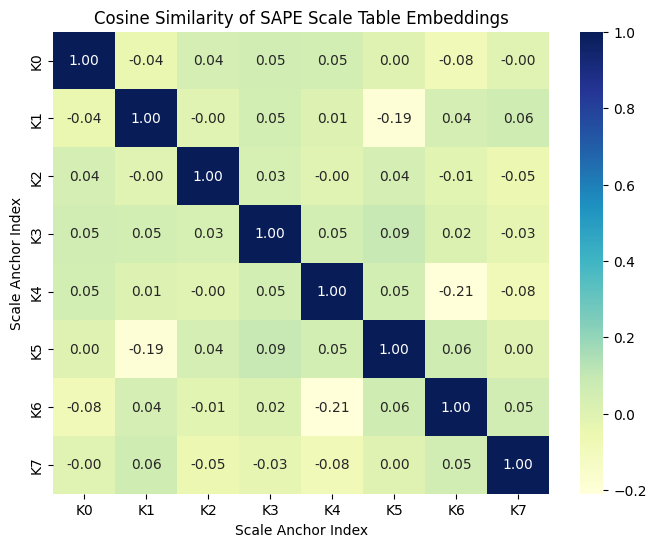

In [37]:
diff = weights1 - weights0
print("Difference between scale tables:\n", diff)
plot_scale_similarity(diff)

In [42]:
def scale_spline_point(scale_table: torch.Tensor, s: torch.Tensor):
    """
    Compute one point on the scale spline.

    Args:
        scale_table: Tensor of shape (K, d)
        s: scalar tensor in [0, 1]

    Returns:
        Tensor of shape (d,)
    """
    K, d = scale_table.shape
    device = scale_table.device

    # ensure tensor
    if not torch.is_tensor(s):
        s = torch.tensor(s, device=device, dtype=torch.float32)
    else:
        s = s.to(device).float()

    s = s.clamp(0.0, 1.0)

    # continuous index
    t = s * (K - 1)
    i0 = torch.floor(t).long()
    i1 = torch.clamp(i0 + 1, max=K - 1)

    alpha = t - i0.float()

    # linear spline interpolation
    return (1.0 - alpha) * scale_table[i0] + alpha * scale_table[i1]


@torch.no_grad()
def sample_scale_spline(scale_table, num_points=25):
    """
    Sample the full scale spline.

    Returns:
        s_vals: (N,)
        curve: (N, d)
    """
    s_vals = torch.linspace(0, 1, num_points, device=scale_table.device)
    curve = torch.stack([scale_spline_point(scale_table, s) for s in s_vals], dim=0)
    return s_vals.cpu(), curve.cpu()



In [43]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def plot_scale_spline_from_table(scale_table, curve):
    table = scale_table.detach().cpu().numpy()
    curve = curve.numpy()

    pca = PCA(n_components=2)
    proj = pca.fit_transform(
        torch.cat([torch.tensor(curve), torch.tensor(table)], dim=0)
    )

    curve_2d = proj[: len(curve)]
    table_2d = proj[len(curve) :]

    plt.figure(figsize=(6, 6))
    plt.plot(curve_2d[:, 0], curve_2d[:, 1], "-k", label="Scale spline")
    plt.scatter(table_2d[:, 0], table_2d[:, 1], c="red", s=60, label="Control points")

    for i, (x, y) in enumerate(table_2d):
        plt.text(x, y, f"{i}", fontsize=9)

    plt.legend()
    plt.axis("equal")
    plt.grid(True)
    plt.show()



tensor([0.0000, 0.0050, 0.0101, 0.0151, 0.0201, 0.0251, 0.0302, 0.0352, 0.0402,
        0.0452, 0.0503, 0.0553, 0.0603, 0.0653, 0.0704, 0.0754, 0.0804, 0.0854,
        0.0905, 0.0955, 0.1005, 0.1055, 0.1106, 0.1156, 0.1206, 0.1256, 0.1307,
        0.1357, 0.1407, 0.1457, 0.1508, 0.1558, 0.1608, 0.1658, 0.1709, 0.1759,
        0.1809, 0.1859, 0.1910, 0.1960, 0.2010, 0.2060, 0.2111, 0.2161, 0.2211,
        0.2261, 0.2312, 0.2362, 0.2412, 0.2462, 0.2513, 0.2563, 0.2613, 0.2663,
        0.2714, 0.2764, 0.2814, 0.2864, 0.2915, 0.2965, 0.3015, 0.3065, 0.3116,
        0.3166, 0.3216, 0.3266, 0.3317, 0.3367, 0.3417, 0.3467, 0.3518, 0.3568,
        0.3618, 0.3668, 0.3719, 0.3769, 0.3819, 0.3869, 0.3920, 0.3970, 0.4020,
        0.4070, 0.4121, 0.4171, 0.4221, 0.4271, 0.4322, 0.4372, 0.4422, 0.4472,
        0.4523, 0.4573, 0.4623, 0.4673, 0.4724, 0.4774, 0.4824, 0.4874, 0.4925,
        0.4975, 0.5025, 0.5075, 0.5126, 0.5176, 0.5226, 0.5276, 0.5327, 0.5377,
        0.5427, 0.5477, 0.5528, 0.5578, 

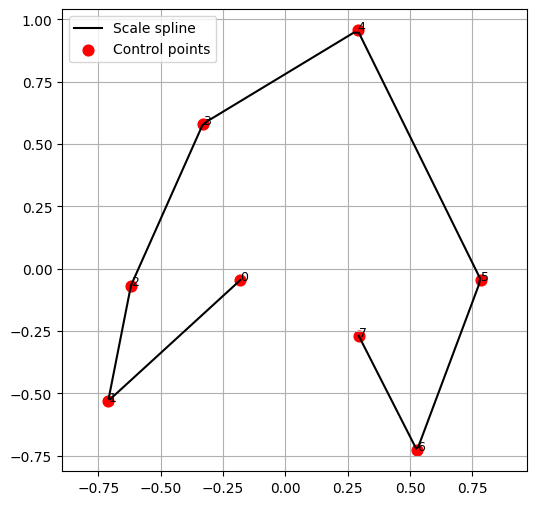

In [46]:
s_vals, curve = sample_scale_spline(weights0, 200)

print(s_vals)
print(curve.shape)  # (N, d)
plot_scale_spline_from_table(weights0, curve)

tensor([0.0000, 0.0050, 0.0101, 0.0151, 0.0201, 0.0251, 0.0302, 0.0352, 0.0402,
        0.0452, 0.0503, 0.0553, 0.0603, 0.0653, 0.0704, 0.0754, 0.0804, 0.0854,
        0.0905, 0.0955, 0.1005, 0.1055, 0.1106, 0.1156, 0.1206, 0.1256, 0.1307,
        0.1357, 0.1407, 0.1457, 0.1508, 0.1558, 0.1608, 0.1658, 0.1709, 0.1759,
        0.1809, 0.1859, 0.1910, 0.1960, 0.2010, 0.2060, 0.2111, 0.2161, 0.2211,
        0.2261, 0.2312, 0.2362, 0.2412, 0.2462, 0.2513, 0.2563, 0.2613, 0.2663,
        0.2714, 0.2764, 0.2814, 0.2864, 0.2915, 0.2965, 0.3015, 0.3065, 0.3116,
        0.3166, 0.3216, 0.3266, 0.3317, 0.3367, 0.3417, 0.3467, 0.3518, 0.3568,
        0.3618, 0.3668, 0.3719, 0.3769, 0.3819, 0.3869, 0.3920, 0.3970, 0.4020,
        0.4070, 0.4121, 0.4171, 0.4221, 0.4271, 0.4322, 0.4372, 0.4422, 0.4472,
        0.4523, 0.4573, 0.4623, 0.4673, 0.4724, 0.4774, 0.4824, 0.4874, 0.4925,
        0.4975, 0.5025, 0.5075, 0.5126, 0.5176, 0.5226, 0.5276, 0.5327, 0.5377,
        0.5427, 0.5477, 0.5528, 0.5578, 

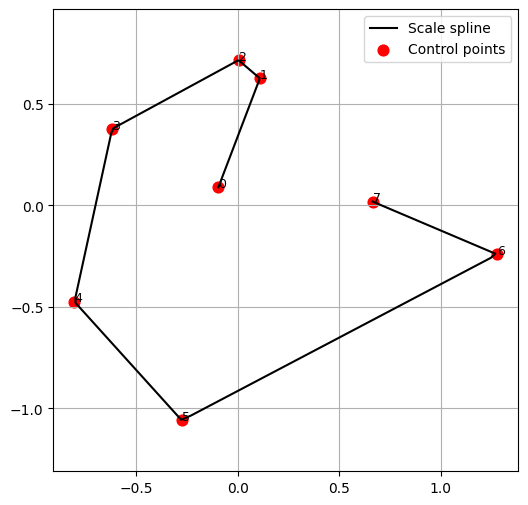

In [47]:
s_vals, curve = sample_scale_spline(weights1, 200)

print(s_vals)
print(curve.shape)  # (N, d)
plot_scale_spline_from_table(weights1, curve)

In [6]:
from torch import nn
import torch

class ScaleEmbedder(nn.Module):
    """
    Combine:
      - a small learned table of K embeddings (interpolated by s in [0,1])
      - a sinusoidal encoding of s projected to d_model
      - optional per-level learnable bias
    Forward API:
      forward(s_scalar, B, L) -> (B, L, d_model)
      where s_scalar is float or 0-d tensor in [0,1],
            B batch size, L length (H*W flattened)
    """

    def __init__(self, d_model, K=8, sinus_dim=64, use_level_bias=False, device=None):
        super().__init__()
        self.d_model = d_model
        self.K = K
        self.sinus_dim = sinus_dim
        self.use_level_bias = use_level_bias

        # table of embeddings to interpolate (K x d_model)
        self.scale_table = nn.Parameter(torch.randn(K, d_model))

        # project sinusoidal encoding to d_model
        self.sinus_proj = nn.Linear(sinus_dim, d_model)

        if use_level_bias:
            # small bias vector to allow per-level shift (will be indexed externally)
            # However we still allow external per-level bias if needed.
            self.level_bias = nn.Parameter(torch.zeros(1, 1, d_model))

        # init
        nn.init.trunc_normal_(self.scale_table, std=0.02)
        nn.init.xavier_uniform_(self.sinus_proj.weight)
        nn.init.normal_(self.sinus_proj.bias, std=1e-6)

    def _sinusoidal_encoding(self, s_scalar):
        # s_scalar: python float or tensor 0-d or shape (...,)
        # produce vector of length sinus_dim
        if not torch.is_tensor(s_scalar):
            s = torch.tensor([s_scalar], dtype=torch.float32)
        else:
            s = s_scalar.reshape(-1)
        device = s.device
        dim = self.sinus_dim
        # create freqs
        freqs = torch.exp(
            torch.arange(0, dim, 2, device=device) * (-torch.log(10000.0) / dim)
        )
        # s may be multiple but we expect scalar -> produce (dim,)
        s = s.to(device).float()
        sin = torch.sin(s.unsqueeze(-1) * freqs)  # (1, dim/2)
        cos = torch.cos(s.unsqueeze(-1) * freqs)
        enc = torch.cat([sin, cos], dim=-1).view(-1)[:dim]  # (dim,)
        return enc  # 1D tensor length sinus_dim

    def forward(self, s_scalar, B, L, device=None, level_idx=None):
        """
        s_scalar : float or 0-d tensor in [0,1] (global for this level)
        B : batch size
        L : sequence length (H*W)
        level_idx: optional int for indexing per-level bias (not used by default)
        returns: tensor (B, L, d_model)
        """
        if device is None:
            device = self.scale_table.device

        # --- interpolation on table ---
        if not isinstance(s_scalar, torch.Tensor):
            s = torch.tensor(s_scalar, device=device)
        else:
            s = s_scalar.to(device)
        s = s.clamp(0.0, 1.0)
        idx = s * (self.K - 1)
        low = torch.floor(idx).long()
        high = torch.ceil(idx).long()
        alpha = idx - low

        low_vec = self.scale_table[low]  # (d_model,)
        high_vec = self.scale_table[high]
        interp = (1.0 - alpha) * low_vec + alpha * high_vec  # (d_model,)

        # --- sinusoidal part ---
        sinus = self._sinusoidal_encoding(s_scalar).to(device)  # (sinus_dim,)
        sinus_proj = self.sinus_proj(sinus)  # (d_model,)

        # combine
        combined = (interp + sinus_proj) * 0.5  # (d_model,)

        # optional level bias (broadcast)
        if self.use_level_bias:
            combined = combined + self.level_bias.view(-1)

        # expand to (B, L, d_model)
        out = (
            combined.view(1, 1, self.d_model)
            .expand(B, L, self.d_model)
            .contiguous()
            .to(device)
        )
        return out

In [7]:
def inspect_scale_rows(scale_embedder, scale_values):
    used_rows = set()

    for level, s in enumerate(scale_values):
        device = scale_embedder.scale_table.device

        s_t = torch.tensor(s, device=device)
        s_t = s_t.clamp(0.0, 1.0)

        idx = s_t * (scale_embedder.K - 1)
        low = torch.floor(idx).long().item()
        high = torch.ceil(idx).long().item()
        alpha = (idx - low).item()

        used_rows.add(low)
        used_rows.add(high)

        print(
            f"Level {level}: "
            f"s={s:.2f}, "
            f"idx={idx:.2f}, "
            f"low={low}, high={high}, alpha={alpha:.3f}"
        )

    print("\nUsed scale_table rows:", sorted(used_rows))
    print("Unused rows:", sorted(set(range(scale_embedder.K)) - used_rows))

In [29]:
import math
strides= [8, 16, 32, 64]

max_log_stride = math.log2(max(strides))
log_min = math.log2(min(strides))
log_max = math.log2(max(strides))

# s = (log_s - log_min) / (log_max - log_min)

scale_values = [
    (math.log2(s) - log_min) / (log_max - log_min)  for s in strides
]
print(scale_values)

embedder = ScaleEmbedder(d_model=256, K=8, sinus_dim=64).cuda()

inspect_scale_rows(embedder, scale_values)

[0.0, 0.3333333333333333, 0.6666666666666666, 1.0]
Level 0: s=0.00, idx=0.00, low=0, high=0, alpha=0.000
Level 1: s=0.33, idx=2.33, low=2, high=3, alpha=0.333
Level 2: s=0.67, idx=4.67, low=4, high=5, alpha=0.667
Level 3: s=1.00, idx=7.00, low=7, high=7, alpha=0.000

Used scale_table rows: [0, 2, 3, 4, 5, 7]
Unused rows: [1, 6]
